In [1]:
%load_ext autoreload
%autoreload 2
from data_preparation import get_data_from_Kaggle, divide_into_img_gt, concat_folders, \
    rename_folder, rename_files_in_folder, rename_files_sequentialy, rename_folders_sequentialy, \
    flatten_folders, split_test_val_test, create_density_map, create_density_maps_in_folders
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL.Image as Image
import torch

e:\OneDrive\Pulpit\MSC-thesis\data_preparation.py:91: SyntaxWarning: invalid escape sequence '\{'
  new_folder = f"data\{parent_name}_{sub}"
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Fetching data

In [ ]:
destination_path = r"E:\OneDrive\Pulpit\MSC-thesis\data"
datasets = ["tthien/shanghaitech", "tthien/ucfcc50", "anhhhhtx/ucf-qnrf"]
for dataset in datasets:
    get_data_from_Kaggle(dataset, destination_path)

### Changing folder hierarchy

In [8]:
paths = [r"data\UCF-QNRF_ECCV18\Test",
         r"data\UCF-QNRF_ECCV18\Train",
         r"data\UCF_CC_50"]
for path in paths:
    divide_into_img_gt(path)

In [12]:
concat_folders(r"data\NWPU-Crowd")

In [14]:
rename_folder(r'data\NWPU-Crowd\mats', 'matrices')
rename_files_in_folder(r'data\NWPU-Crowd\matrices')

In [4]:
rename_files_sequentialy(r'data\ShanghaiTech')

In [ ]:
rename_folders_sequentialy(r'data\ShanghaiTech')


In [12]:
rename_folders_sequentialy(r'data\ShanghaiTech', 'ground-truth', 'matrices')

In [14]:
flatten_folders(r'data\ShanghaiTech')

In [ ]:
split_test_val_test(r'data\NWPU-Crowd')

In [29]:
rename_folders_sequentialy(r'data\jhu_crowd_v2.0', 'gt', 'matrices')
rename_files_sequentialy(r'data\jhu_crowd_v2.0', folder='matrices', prefix='ann_')

<unknown>:87: SyntaxWarning: invalid escape sequence '\{'
<unknown>:87: SyntaxWarning: invalid escape sequence '\{'


### Creating density maps

In [23]:
# img = plt.imread(r'data\ShanghaiTech_part_B\test\images\IMG_1.jpg')
# mat = scipy.io.loadmat(r'data\ShanghaiTech_part_B\test\matrices\ann_GT_IMG_1.mat')
# points = mat['image_info']
# map = create_density_map(img,points[0,0][0,0][0], k=3)
# mat = scipy.io.loadmat(r'data\UCF-QNRF_ECCV18\Train\matrices\img_1201_ann.mat')
# points = mat['annPoints']


img = plt.imread(r'data\UCF-QNRF_ECCV18\Test\images\img_0330.jpg')
mat = scipy.io.loadmat(r'data\UCF-QNRF_ECCV18\Test\matrices\img_0330_ann.mat')
points = mat['annPoints']
map = create_density_map(img,points, k=5)
# points

# mat = scipy.io.loadmat(r'data\NWPU-Crowd\train\matrices\ann_3169.mat')
# points = mat['annPoints']
# points

# mat = scipy.io.loadmat(r'data\NWPU-Crowd\train\matrices\ann_3169.mat')
# points = mat['annPoints']
# points

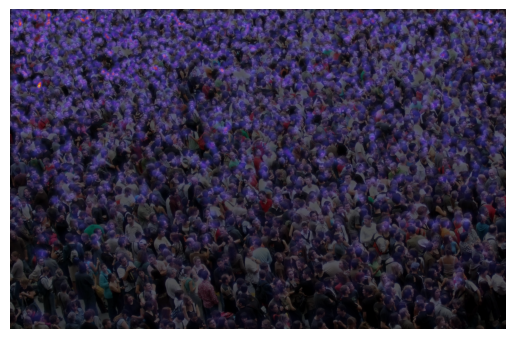

tensor(1654.1140)
1668
[[  19.10562308   11.8280146 ]
 [  17.69466736   44.30210787]
 [  69.90002884   31.59485398]
 ...
 [1257.16932573 1021.59242054]
 [1081.14224515  861.76415105]
 [ 635.01064711  124.1509247 ]]


In [27]:
img = Image.open(r'data\UCF-QNRF_ECCV18\Test\images\img_0330.jpg')

plt.imshow(img)
plt.imshow(map, cmap='CMRmap', alpha=0.7)

plt.axis('off')
plt.show()


print(map.sum())
print(len(points))
print(points)

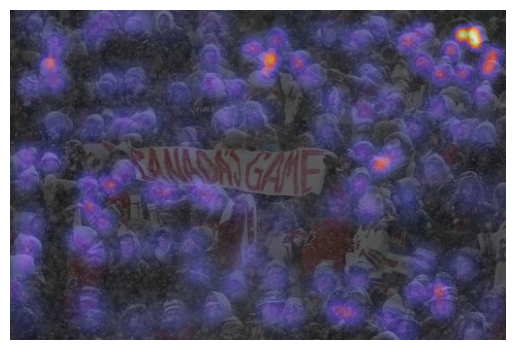

tensor(108.1143)
111
[[164 189]
 [338 202]
 [ 17 151]
 [444  67]
 [406 195]
 [ 86 122]
 [498  47]
 [455  42]
 [476 333]
 [ 81 300]
 [389 318]
 [269  51]
 [ 81 203]
 [223 112]
 [184 133]
 [130 324]
 [ 85  25]
 [381  19]
 [425  55]
 [100   9]
 [160  11]
 [ 47  35]
 [253 108]
 [207  77]
 [280 219]
 [ 81 179]
 [122 246]
 [445 307]
 [407 331]
 [ 19 242]
 [274 277]
 [370 208]
 [116 116]
 [466 265]
 [290 314]
 [485  87]
 [488 128]
 [441 100]
 [358 279]
 [247 254]
 [210 310]
 [276  31]
 [ 15 261]
 [296  54]
 [332  94]
 [424  23]
 [369  66]
 [ 22 219]
 [ 95 219]
 [188 239]
 [381 161]
 [409  34]
 [231 283]
 [473 189]
 [174  85]
 [ 83 320]
 [356  31]
 [268 310]
 [363 146]
 [478  24]
 [416 122]
 [499 305]
 [466  26]
 [506 197]
 [141 115]
 [ 88 251]
 [394 151]
 [360 181]
 [100  75]
 [103 181]
 [ 47  74]
 [493  61]
 [ 16 317]
 [194 271]
 [155 242]
 [325  24]
 [ 22  78]
 [ 16 174]
 [324 282]
 [443 289]
 [232  81]
 [250  40]
 [  4 288]
 [419 292]
 [364 107]
 [208 195]
 [210  15]
 [ 70 237]
 [ 42 155]


In [11]:
points = []
matrix_path = r'data\jhu_crowd_v2.0\train\matrices\ann_0015.txt'
with open(matrix_path, "r") as f:
    for line in f:
        numbers = np.int32(line.split())
        points.append(numbers[:2])

points = np.array(points)

img = plt.imread(r'data\jhu_crowd_v2.0\train\images\0015.jpg')
map = create_density_map(img,points, k=3)
img = Image.open(r'data\jhu_crowd_v2.0\train\images\0015.jpg')

plt.imshow(img)
plt.imshow(map, cmap='CMRmap', alpha=0.6)

plt.axis('off')
plt.show()


print(map.sum())
print(len(points))
print(points)

In [14]:
create_density_maps_in_folders(r'data\UCF_CC_50', ann_first=False)

In [12]:
create_density_maps_in_folders(r'data\UCF-QNRF_ECCV18',ann_first=False)

img_0302_ann
Skipped invalid slice at point (892, 280) with sigma=26.459319389285827
Skipped invalid slice at point (891, 263) with sigma=25.54446043291299
Skipped invalid slice at point (894, 261) with sigma=26.209245755770976
img_0303_ann
img_0304_ann
img_0305_ann
img_0306_ann
Skipped invalid slice at point (-1076, 719) with sigma=332.4315495088775
img_0307_ann
img_0308_ann
img_0309_ann
img_0310_ann
img_0311_ann
img_0312_ann
img_0313_ann
img_0314_ann
img_0315_ann
img_0316_ann
img_0317_ann
img_0318_ann
img_0319_ann
img_0320_ann
img_0321_ann
img_0322_ann
img_0323_ann
img_0324_ann
img_0325_ann
img_0326_ann
img_0327_ann
img_0328_ann
img_0329_ann
img_0330_ann
img_0331_ann
img_0332_ann
img_0333_ann
img_0334_ann
img_0001_ann
img_0002_ann
img_0003_ann
img_0004_ann
img_0005_ann
img_0006_ann
img_0007_ann
img_0008_ann
img_0009_ann
img_0010_ann
img_0011_ann
img_0012_ann
img_0013_ann
img_0014_ann
img_0015_ann
img_0016_ann
img_0017_ann
Skipped invalid slice at point (5375, 1890) with sigma=147.967

In [13]:
create_density_maps_in_folders(r'data\jhu_crowd_v2.0',ann_first=True, mat_format = '.txt')

<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
e:\OneDrive\Pulpit\MSC-thesis\data_preparation.py:91: SyntaxWarning: invalid escape sequence '\{'
  new_folder = f"data\{parent_name}_{sub}"


UnidentifiedImageError: cannot identify image file 'data\\jhu_crowd_v2.0\\val\\images\\val.txt'

In [23]:
create_density_maps_in_folders(r'data\NWPU-Crowd\train',ann_first=True)

<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


ann_0480
ann_0481
ann_0482
ann_0483
ann_0484
ann_0485
ann_0486
ann_0487
ann_0488
ann_0489
ann_0490
ann_0491
ann_0492
ann_0493
ann_0494
ann_0495
ann_0496
ann_0497
ann_0498
ann_0499
ann_0500
ann_0501
ann_0502
ann_0503
ann_0504
ann_0505
ann_0506
ann_0507
ann_0508
ann_0509
ann_0510
ann_0511
ann_0512
ann_0513
ann_0514
ann_0515
ann_0516
ann_0517
ann_0518
ann_0519
ann_0520
ann_0521
ann_0522
ann_0523
ann_0524
ann_0525
ann_0526
ann_0527
ann_0528
ann_0529
ann_0530
ann_0531
ann_0532
ann_0533
ann_0534
ann_0535
ann_0536
ann_0537
ann_0538
ann_0539
ann_0540
ann_0541
ann_0542
ann_0543
ann_0544
ann_0545
ann_0546
ann_0547
ann_0548
ann_0549
ann_0550
ann_0551
ann_0552
ann_0553
ann_0554
ann_0555
ann_0556
ann_0557
ann_0558
ann_0559
ann_0560
ann_0561
ann_0562
ann_0563
ann_0564
ann_0565
ann_0566
ann_0567
ann_0568
ann_0569
ann_0570
ann_0571
ann_0572
ann_0573
ann_0574
ann_0575
ann_0576
ann_0577
ann_0578
ann_0579
ann_0580
ann_0581
ann_0582
ann_0583
ann_0584
ann_0585
ann_0586
ann_0587
ann_0588
ann_0589
ann_0590
a

In [9]:
create_density_maps_in_folders(r'data\NWPU-Crowd\val',ann_first=True)

<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
<unknown>:91: SyntaxWarning: invalid escape sequence '\{'


ann_3098
ann_3110
ann_3111
ann_3112
ann_3113
ann_3114
ann_3115
ann_3116
ann_3117
ann_3118
ann_3119
ann_3120
ann_3121
ann_3122
ann_3123
ann_3124
ann_3125
ann_3126
ann_3127
ann_3128
ann_3129
ann_3130
ann_3131
ann_3132
ann_3133
ann_3134
ann_3135
ann_3136
ann_3137
ann_3138
ann_3139
ann_3140
ann_3141
ann_3142
ann_3143
ann_3144
ann_3145
ann_3146
ann_3147
ann_3148
ann_3149
ann_3150
ann_3151
ann_3152
ann_3153
ann_3154
ann_3155
ann_3156
ann_3157
ann_3158
ann_3159
ann_3160
ann_3161
ann_3162
ann_3163
ann_3164
ann_3165
ann_3166
ann_3167
ann_3168
ann_3170
ann_3171
ann_3172
ann_3173
ann_3174
ann_3175
ann_3176
ann_3177
ann_3178
ann_3179
ann_3180
ann_3181
ann_3182
ann_3183
ann_3184
ann_3185
ann_3186
ann_3187
ann_3188
ann_3189
ann_3190
ann_3191
ann_3192
ann_3193
ann_3194
ann_3195
ann_3196
ann_3197
ann_3198
ann_3199
ann_3200
ann_3201
ann_3202
ann_3203
ann_3204
ann_3205
ann_3206
ann_3207
ann_3208
ann_3209
ann_3210
ann_3211
ann_3212
ann_3213
ann_3214
ann_3215
ann_3216
ann_3217
ann_3218
ann_3219
ann_3220
a

In [5]:
create_density_maps_in_folders(r'data\ShanghaiTech_part_A',ann_first=True, is_shanghai=True)

<unknown>:91: SyntaxWarning: invalid escape sequence '\{'
<unknown>:91: SyntaxWarning: invalid escape sequence '\{'


ann_GT_IMG_1
ann_GT_IMG_10
ann_GT_IMG_100
ann_GT_IMG_101
ann_GT_IMG_102
ann_GT_IMG_103
ann_GT_IMG_104
ann_GT_IMG_105
ann_GT_IMG_106
ann_GT_IMG_107
ann_GT_IMG_108
ann_GT_IMG_109
ann_GT_IMG_11
ann_GT_IMG_110
ann_GT_IMG_111
ann_GT_IMG_112
ann_GT_IMG_113
ann_GT_IMG_114
ann_GT_IMG_115
ann_GT_IMG_116
ann_GT_IMG_117
ann_GT_IMG_118
ann_GT_IMG_119
ann_GT_IMG_12
ann_GT_IMG_120
ann_GT_IMG_121
ann_GT_IMG_122
ann_GT_IMG_123
ann_GT_IMG_124
ann_GT_IMG_125
ann_GT_IMG_126
ann_GT_IMG_127
ann_GT_IMG_128
ann_GT_IMG_129
ann_GT_IMG_13
ann_GT_IMG_130
ann_GT_IMG_131
ann_GT_IMG_132
ann_GT_IMG_133
ann_GT_IMG_134
ann_GT_IMG_135
ann_GT_IMG_136
ann_GT_IMG_137
ann_GT_IMG_138
ann_GT_IMG_139
ann_GT_IMG_14
ann_GT_IMG_140
ann_GT_IMG_141
ann_GT_IMG_142
ann_GT_IMG_143
ann_GT_IMG_144
ann_GT_IMG_145
ann_GT_IMG_146
ann_GT_IMG_147
ann_GT_IMG_148
ann_GT_IMG_149
ann_GT_IMG_15
ann_GT_IMG_150
ann_GT_IMG_151
ann_GT_IMG_152
ann_GT_IMG_153
ann_GT_IMG_154
ann_GT_IMG_155
ann_GT_IMG_156
ann_GT_IMG_157
ann_GT_IMG_158
ann_GT_IMG_159
ann

In [6]:
create_density_maps_in_folders(r'data\ShanghaiTech_part_B',ann_first=True, is_shanghai=True)

ann_GT_IMG_1
ann_GT_IMG_10
ann_GT_IMG_100
ann_GT_IMG_101
ann_GT_IMG_102
ann_GT_IMG_103
ann_GT_IMG_104
ann_GT_IMG_105
ann_GT_IMG_106
ann_GT_IMG_107
ann_GT_IMG_108
ann_GT_IMG_109
ann_GT_IMG_11
ann_GT_IMG_110
ann_GT_IMG_111
ann_GT_IMG_112
ann_GT_IMG_113
ann_GT_IMG_114
ann_GT_IMG_115
ann_GT_IMG_116
ann_GT_IMG_117
ann_GT_IMG_118
ann_GT_IMG_119
ann_GT_IMG_12
ann_GT_IMG_120
ann_GT_IMG_121
ann_GT_IMG_122
ann_GT_IMG_123
ann_GT_IMG_124
ann_GT_IMG_125
ann_GT_IMG_126
ann_GT_IMG_127
ann_GT_IMG_128
ann_GT_IMG_129
ann_GT_IMG_13
ann_GT_IMG_130
ann_GT_IMG_131
ann_GT_IMG_132
ann_GT_IMG_133
ann_GT_IMG_134
ann_GT_IMG_135
ann_GT_IMG_136
ann_GT_IMG_137
ann_GT_IMG_138
ann_GT_IMG_139
ann_GT_IMG_14
ann_GT_IMG_140
ann_GT_IMG_141
ann_GT_IMG_142
ann_GT_IMG_143
ann_GT_IMG_144
ann_GT_IMG_145
ann_GT_IMG_146
ann_GT_IMG_147
ann_GT_IMG_148
ann_GT_IMG_149
ann_GT_IMG_15
ann_GT_IMG_150
ann_GT_IMG_151
ann_GT_IMG_152
ann_GT_IMG_153
ann_GT_IMG_154
ann_GT_IMG_155
ann_GT_IMG_156
ann_GT_IMG_157
ann_GT_IMG_158
ann_GT_IMG_159
ann